In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# importing raw data
X_train = pd.read_csv("train.csv",sep= ',' )
X_test = pd.read_csv('Test.csv',sep=',')
X_train
# change "date" dtype to datetime with format %Y/%m/%d





,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30552,YWSFY6Q X 2020-03-15,2020-03-15,YWSFY6Q,22.0,14.0,83.0,3848.86,72,6.700000,68.300003,...,54.302954,12.312248,49.871571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30553,YWSFY6Q X 2020-03-16,2020-03-16,YWSFY6Q,53.0,30.0,146.0,9823.87,72,6.300000,77.700005,...,36.170757,-129.236726,49.779531,1863.555567,3475.020107,0.052920,-96.149506,33.230234,-157.067467,49.912310
30554,YWSFY6Q X 2020-03-17,2020-03-17,YWSFY6Q,85.0,52.0,153.0,8900.85,72,7.100000,68.500000,...,8.955216,-162.856069,48.459205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30555,YWSFY6Q X 2020-03-18,2020-03-18,YWSFY6Q,103.0,33.0,149.0,13963.90,72,19.100000,66.300003,...,17.974815,-168.906764,47.293537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


X_train.columns = X_train.columns.str.replace(" ", "_")
X_test.columns = X_test.columns.str.replace(" ", "_")

In [2]:
X_train.columns

Index(['Place_ID X Date', 'Date', 'Place_ID', 'target', 'target_min',
       'target_max', 'target_variance', 'target_count',
       'precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground',
       'L3_NO2_NO2_column_number_density',
       'L3_NO2_NO2_slant_column_number_density',
       'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction',
       'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle',
       'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle',
       'L3_NO2_solar_zenith_angle',
       'L3_NO2_stratospheric_NO2_column_number_density',
       'L3_NO2_tropopause_pressure',
       'L3_NO2_tropospheric_NO2_column_number_density',
       'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature',
       'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle',
   

In [3]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

In [4]:
X_train.describe()

,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
count,30557.000000,30557.000000,30557.000000,3.055700e+04,30557.000000,30557.000000,30557.000000,30557.000000,30557.000000,30557.000000,...,23320.000000,23320.000000,23320.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000
mean,61.148045,29.025866,117.992234,7.983756e+03,125.831135,15.302326,70.552747,0.006004,9.321342,0.416886,...,35.590916,-123.697777,46.533951,923.231949,1711.793613,0.016227,1.254703,13.849040,-69.098594,23.100630
std,46.861309,33.119775,100.417713,4.863090e+04,146.581856,10.688573,18.807884,0.003787,9.343226,2.707990,...,18.955228,71.916036,14.594267,929.633988,1741.299304,0.027016,55.101250,18.004375,84.702355,24.786350
min,1.000000,1.000000,1.000000,0.000000e+00,2.000000,0.420044,5.128572,0.000139,-34.647879,-15.559646,...,0.000000,-179.880630,0.000000,0.000000,0.000000,0.000000,-105.367363,0.000000,-179.947422,0.000000
25%,25.000000,5.000000,60.000000,1.064920e+03,44.000000,7.666667,58.600002,0.003403,3.123071,-1.097864,...,19.451524,-165.882624,36.693094,0.000000,0.000000,0.000000,0.000000,0.000000,-161.726937,0.000000
50%,50.000000,15.000000,91.000000,2.395350e+03,72.000000,12.200000,74.099998,0.004912,8.478424,0.222092,...,37.918838,-156.637162,47.445010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,80.000000,44.000000,155.000000,5.882550e+03,150.000000,19.900000,85.450001,0.007562,16.201563,1.772925,...,52.270055,-118.453598,57.438181,1861.674119,3393.541633,0.023829,62.245728,27.412303,0.000000,47.090635
max,815.000000,438.000000,999.000000,1.841490e+06,1552.000000,72.599998,100.000000,0.021615,37.437921,17.955124,...,66.111289,179.776125,79.631711,2112.522949,6478.550544,0.210483,77.355232,59.972710,179.813344,69.992363


In [5]:
import numpy as np

X_train = X_train.replace(0, np.nan)

import sweetviz as sv

# Generate report for X_train and target
report = sv.analyze([X_train, "Train Data"], target_feat='target')

# Show the report in the browser
report.show_html('sweetviz_report.html')

In [6]:
type(X_train['Date'][0])

str

In [7]:
X_train['Date'] = pd.to_datetime(X_train['Date'], format = '%Y-%m-%d')
X_test['Date'] = pd.to_datetime(X_test['Date'], format = '%Y-%m-%d')

In [8]:
import missingno as msno

In [9]:
X_train.isna().sum()

Place_ID X Date                     0
Date                                0
Place_ID                            0
target                              0
target_min                          0
                                ...  
L3_CH4_aerosol_optical_depth    27680
L3_CH4_sensor_azimuth_angle     27680
L3_CH4_sensor_zenith_angle      27680
L3_CH4_solar_azimuth_angle      27680
L3_CH4_solar_zenith_angle       27680
Length: 82, dtype: int64

<Axes: >

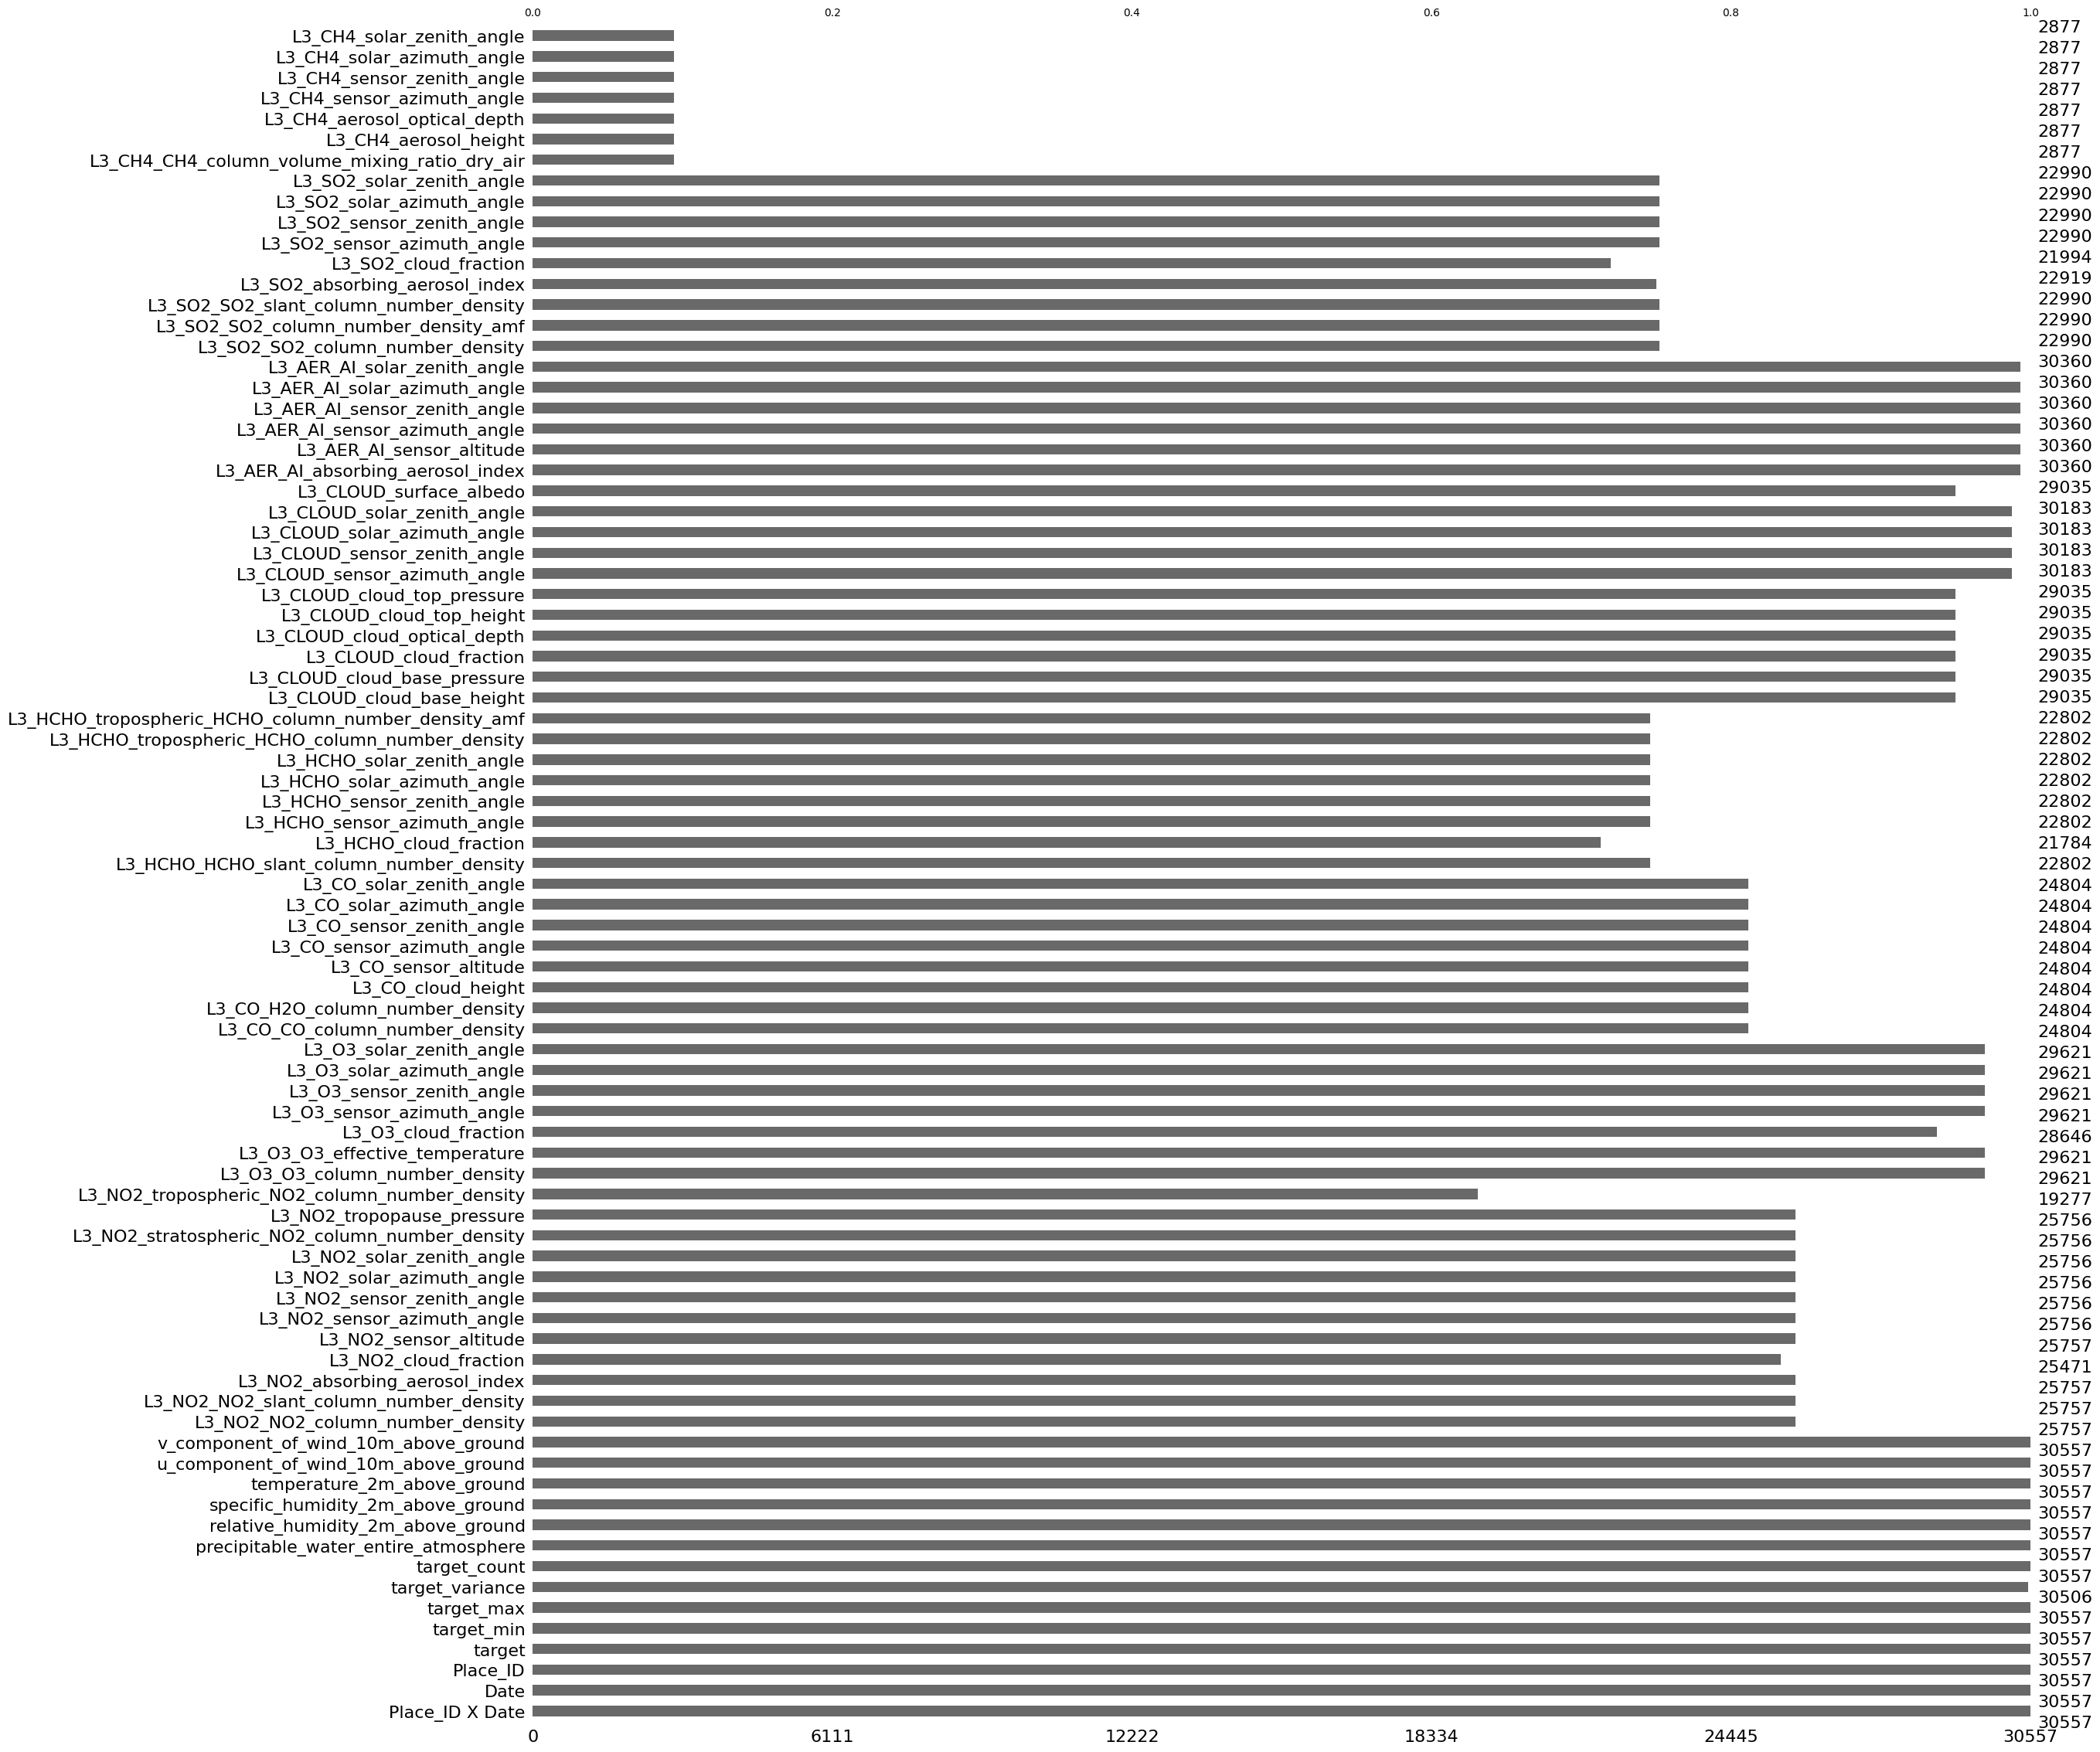

In [10]:
msno.bar(X_train)

<Axes: >

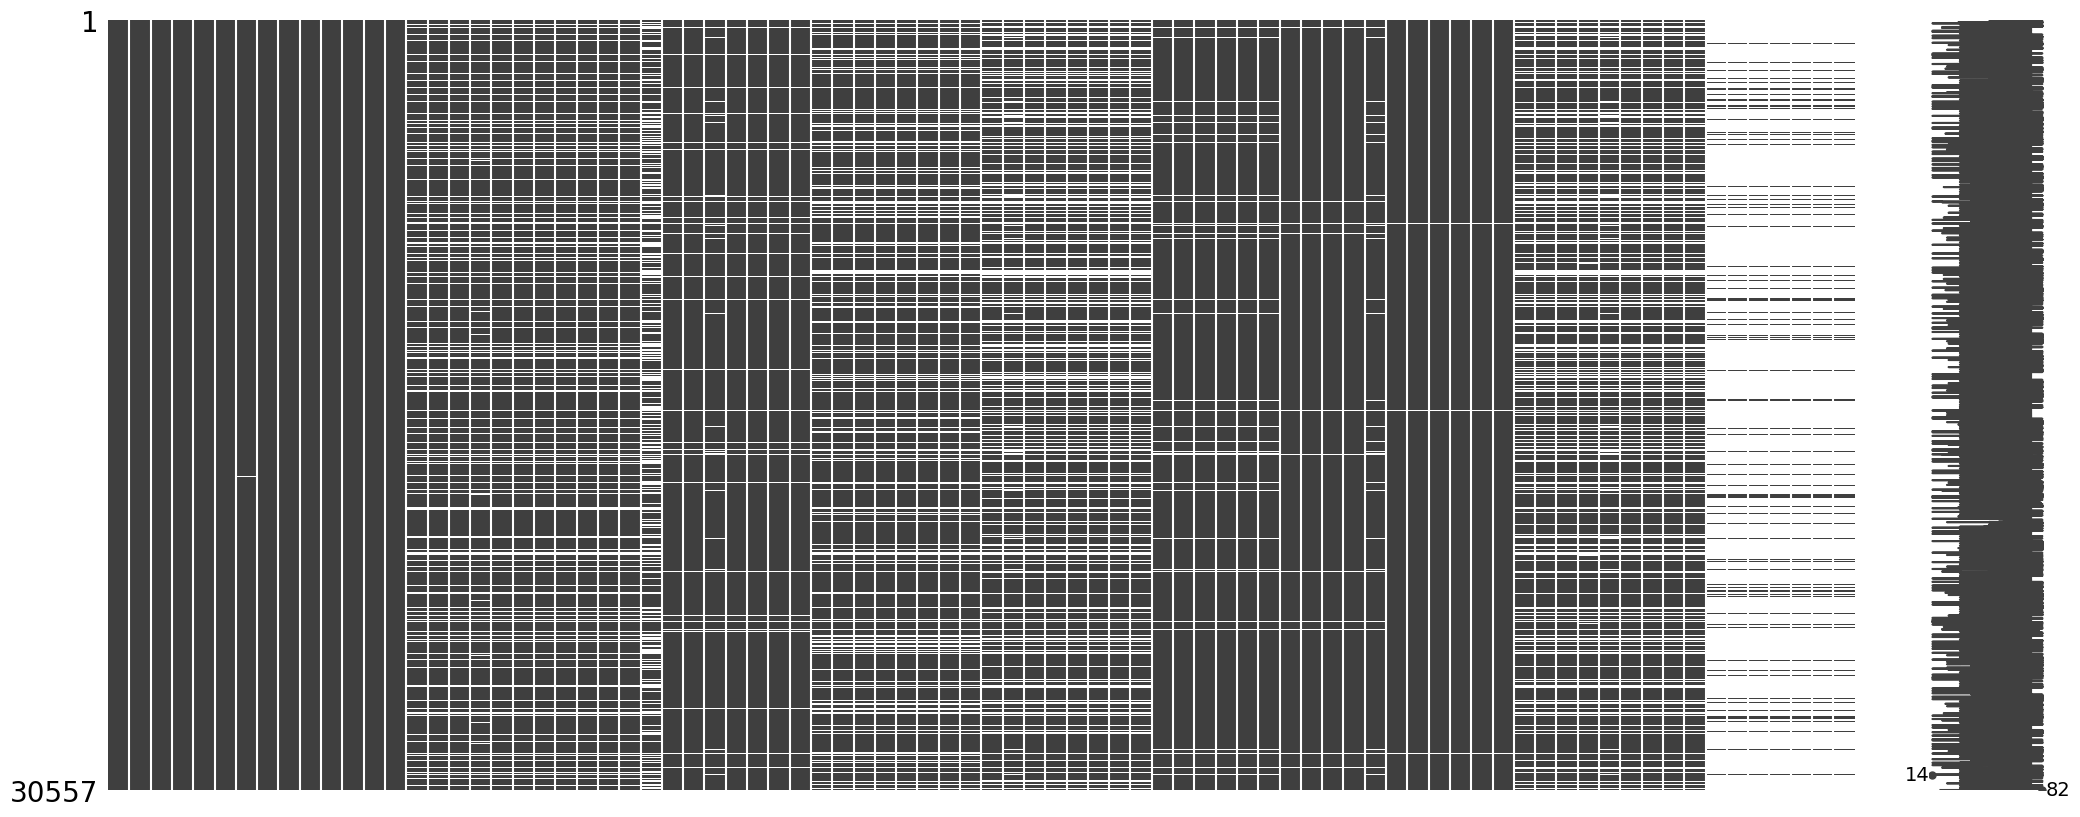

In [11]:
msno.matrix(X_train)

In [12]:
total_rows = len(X_train)
for col in X_train.columns:
    nan_count = X_train[col].isna().sum()
    nan_percent = (nan_count/total_rows)
    print(f"{col}:{nan_percent:.2f}% missing")

Place_ID X Date:0.00% missing
Date:0.00% missing
Place_ID:0.00% missing
target:0.00% missing
target_min:0.00% missing
target_max:0.00% missing
target_variance:0.00% missing
target_count:0.00% missing
precipitable_water_entire_atmosphere:0.00% missing
relative_humidity_2m_above_ground:0.00% missing
specific_humidity_2m_above_ground:0.00% missing
temperature_2m_above_ground:0.00% missing
u_component_of_wind_10m_above_ground:0.00% missing
v_component_of_wind_10m_above_ground:0.00% missing
L3_NO2_NO2_column_number_density:0.16% missing
L3_NO2_NO2_slant_column_number_density:0.16% missing
L3_NO2_absorbing_aerosol_index:0.16% missing
L3_NO2_cloud_fraction:0.17% missing
L3_NO2_sensor_altitude:0.16% missing
L3_NO2_sensor_azimuth_angle:0.16% missing
L3_NO2_sensor_zenith_angle:0.16% missing
L3_NO2_solar_azimuth_angle:0.16% missing
L3_NO2_solar_zenith_angle:0.16% missing
L3_NO2_stratospheric_NO2_column_number_density:0.16% missing
L3_NO2_tropopause_pressure:0.16% missing
L3_NO2_tropospheric_NO2_c

In [13]:
X_train.columns = X_train.columns.str.replace(" ", "_")

In [14]:
X_test = X_test.fillna(X_train.mean,  inplace=True)

In [15]:
X_train.isna().sum()

Place_ID_X_Date                     0
Date                                0
Place_ID                            0
target                              0
target_min                          0
                                ...  
L3_CH4_aerosol_optical_depth    27680
L3_CH4_sensor_azimuth_angle     27680
L3_CH4_sensor_zenith_angle      27680
L3_CH4_solar_azimuth_angle      27680
L3_CH4_solar_zenith_angle       27680
Length: 82, dtype: int64

In [16]:
import pandas as pd

# Set threshold for dropping columns (e.g., 60% missing)
threshold = 0.6

# Identify columns with >60% missing values
high_nan_cols = X_train.columns[X_train.isna().mean() > threshold]
print(f"Dropping {len(high_nan_cols)} columns due to high missingness (>60%):")
print(high_nan_cols.tolist())

# Drop those columns
X_train = X_train.drop(columns=high_nan_cols)
X_train = X_train.select_dtypes(include=[np.number])
# Fill remaining NaNs with median
X_train = X_train.fillna(X_train.mean())

# Optional: check that no NaNs remain
print("Remaining missing values per column:")
print(X_train.isna().sum())

Dropping 7 columns due to high missingness (>60%):
['L3_CH4_CH4_column_volume_mixing_ratio_dry_air', 'L3_CH4_aerosol_height', 'L3_CH4_aerosol_optical_depth', 'L3_CH4_sensor_azimuth_angle', 'L3_CH4_sensor_zenith_angle', 'L3_CH4_solar_azimuth_angle', 'L3_CH4_solar_zenith_angle']
Remaining missing values per column:
target                         0
target_min                     0
target_max                     0
target_variance                0
target_count                   0
                              ..
L3_SO2_cloud_fraction          0
L3_SO2_sensor_azimuth_angle    0
L3_SO2_sensor_zenith_angle     0
L3_SO2_solar_azimuth_angle     0
L3_SO2_solar_zenith_angle      0
Length: 72, dtype: int64


In [17]:
X_train.info

<bound method DataFrame.info of        target  target_min  target_max  target_variance  target_count   
0        38.0        23.0        53.0           769.50            92  \
1        39.0        25.0        63.0          1319.85            91   
2        24.0         8.0        56.0          1181.96            96   
3        49.0        10.0        55.0          1113.67            96   
4        21.0         9.0        52.0          1164.82            95   
...       ...         ...         ...              ...           ...   
30552    22.0        14.0        83.0          3848.86            72   
30553    53.0        30.0       146.0          9823.87            72   
30554    85.0        52.0       153.0          8900.85            72   
30555   103.0        33.0       149.0         13963.90            72   
30556    89.0        46.0       132.0          9393.64            72   

       precipitable_water_entire_atmosphere   
0                                 11.000000  \
1        

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = X_train.select_dtypes(include='number')
df_numeric.drop(['target_min','target_max','target_variance','target_count'], axis=1, inplace=True)

print(df_numeric)



       target  precipitable_water_entire_atmosphere   
0        38.0                             11.000000  \
1        39.0                             14.600000   
2        24.0                             16.400000   
3        49.0                              6.911948   
4        21.0                             13.900001   
...       ...                                   ...   
30552    22.0                              6.700000   
30553    53.0                              6.300000   
30554    85.0                              7.100000   
30555   103.0                             19.100000   
30556    89.0                             11.600000   

       relative_humidity_2m_above_ground  specific_humidity_2m_above_ground   
0                              60.200001                            0.00804  \
1                              48.799999                            0.00839   
2                              33.400002                            0.00750   
3                      

In [19]:
# Compute correlation with target
corr_with_target = df_numeric.corr()['target']

# Select features with absolute correlation > threshold (e.g., 0.2)
threshold = 0.2
important_features = corr_with_target[abs(corr_with_target) > threshold].index.tolist()



In [20]:
filtered_corr = df_numeric[important_features].corr()
print(filtered_corr)

                                                   target   
target                                           1.000000  \
L3_NO2_NO2_column_number_density                 0.291878   
L3_NO2_NO2_slant_column_number_density           0.314300   
L3_NO2_sensor_altitude                          -0.280214   
L3_NO2_tropospheric_NO2_column_number_density    0.242273   
L3_CO_CO_column_number_density                   0.364011   
L3_CO_sensor_altitude                           -0.272867   
L3_HCHO_HCHO_slant_column_number_density         0.285367   
L3_HCHO_tropospheric_HCHO_column_number_density  0.309293   
L3_AER_AI_sensor_altitude                       -0.307659   

                                                 L3_NO2_NO2_column_number_density   
target                                                                   0.291878  \
L3_NO2_NO2_column_number_density                                         1.000000   
L3_NO2_NO2_slant_column_number_density                                   

In [21]:


import plotly.express as px

fig = px.imshow(filtered_corr, 
                text_auto=True,  
                height = 1000, width = 1000,
                color_continuous_midpoint = 0.0,
                range_color=[-1, 1],
                title="Correlation Matrix")

fig.show()

Temperature-only Mean Baseline Metrics:
Mean of target: 9.3213
MSE: 87.2930
RMSE: 9.3431
MAE: 7.5033
R²: 0.0000


<Figure size 1600x600 with 0 Axes>

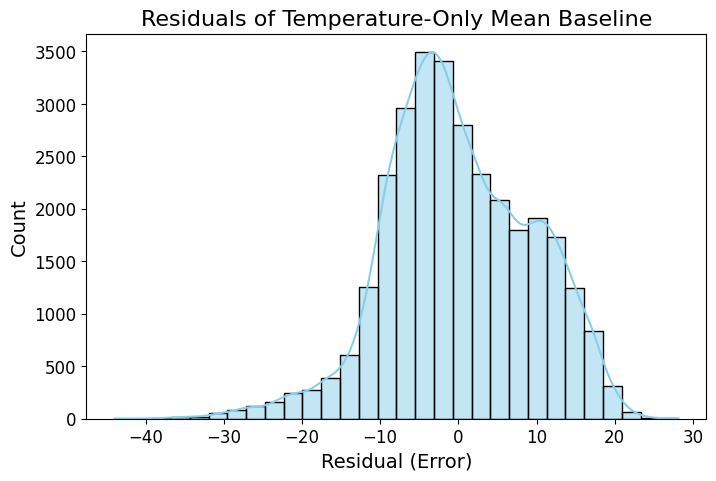

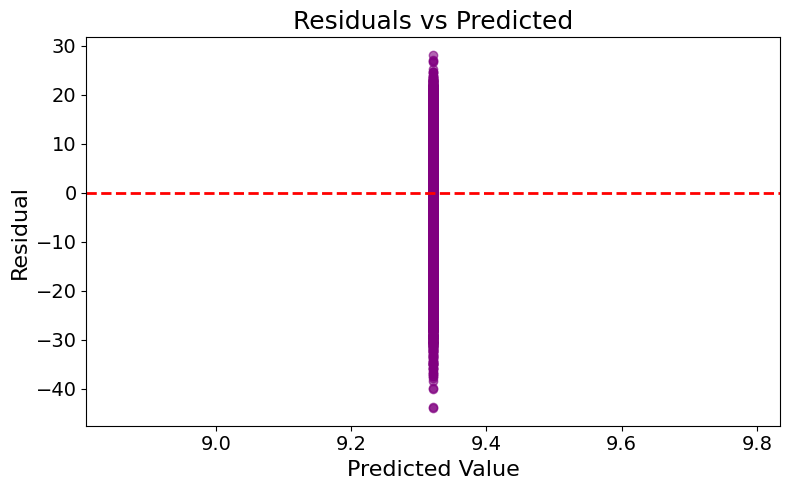

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("Train.csv")
y_true = data['temperature_2m_above_ground']  # target values (e.g., temperature to predict)

# Simple mean baseline prediction
mean_value = y_true.mean()
y_pred = [mean_value] * len(y_true)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Temperature-only Mean Baseline Metrics:")
print(f"Mean of target: {mean_value:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# -----------------------------
# 4️⃣ Residuals
# -----------------------------
residuals = y_true - y_pred

# -----------------------------
# 5️⃣ Plots with larger font
# -----------------------------
plt.figure(figsize=(16,6))
fontsize = 16  # set global font size



# Histogram of Residuals
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color='skyblue', edgecolor='black', stat="count")
plt.xlabel('Residual (Error)', fontsize=14)
plt.ylabel('Count', fontsize=14)  # now y-axis shows counts
plt.title('Residuals of Temperature-Only Mean Baseline', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Value', fontsize=fontsize)
plt.ylabel('Residual', fontsize=fontsize)
plt.title('Residuals vs Predicted', fontsize=fontsize+2)

# Tick label size
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)

plt.tight_layout()
plt.show()

Rolling Mean (3-day lag) Baseline Metrics:
RMSE: 28.0360
MAE: 17.9305
R²: 0.6421


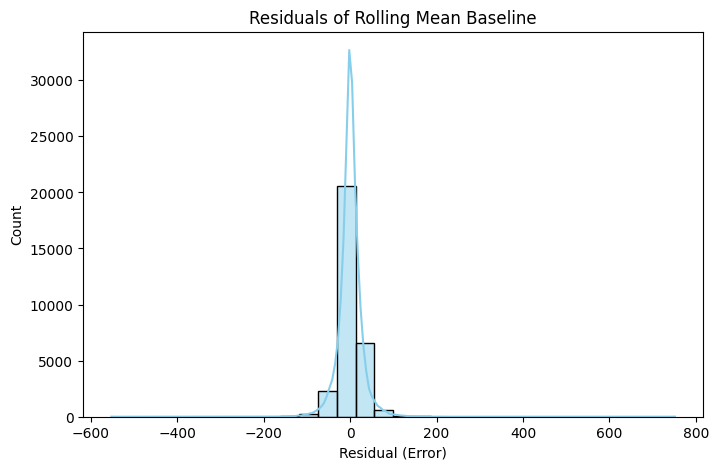

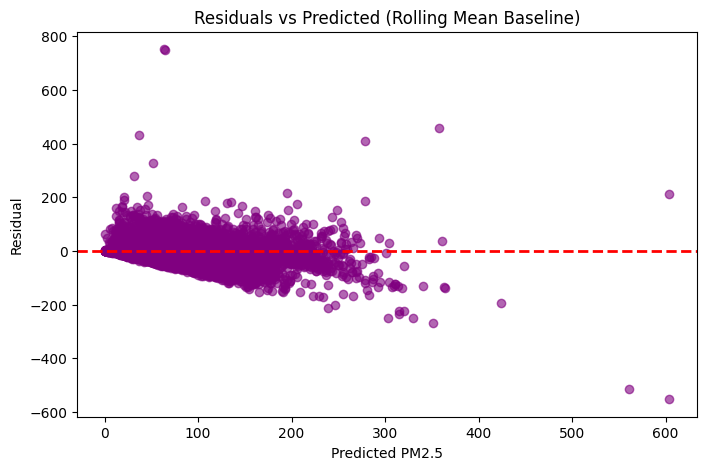

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ----------------------------
#  Load dataset
# ----------------------------
data = pd.read_csv("Train.csv", parse_dates=['Date'])
y_true = data['target']

# ----------------------------
#  Rolling mean baseline (3-day lag) “Predict today using the average of the last 3 days (excluding today)”
# ----------------------------
y_pred = y_true.shift(1).rolling(3).mean()
mean_value = y_true.mean()  # fill first few NaNs with global mean
y_pred = y_pred.fillna(mean_value)

# ----------------------------
#  Compute metrics
# ----------------------------
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Rolling Mean (3-day lag) Baseline Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# ----------------------------
#  Residuals
# ----------------------------
residuals = y_true - y_pred

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color='skyblue', edgecolor='black', stat="count")
plt.xlabel('Residual (Error)')
plt.ylabel('Count')
plt.title('Residuals of Rolling Mean Baseline')
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted PM2.5')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (Rolling Mean Baseline)')
plt.show()

Metrics on training data:
RMSE: 25.1799
MAE: 15.7699
R²: 0.7113


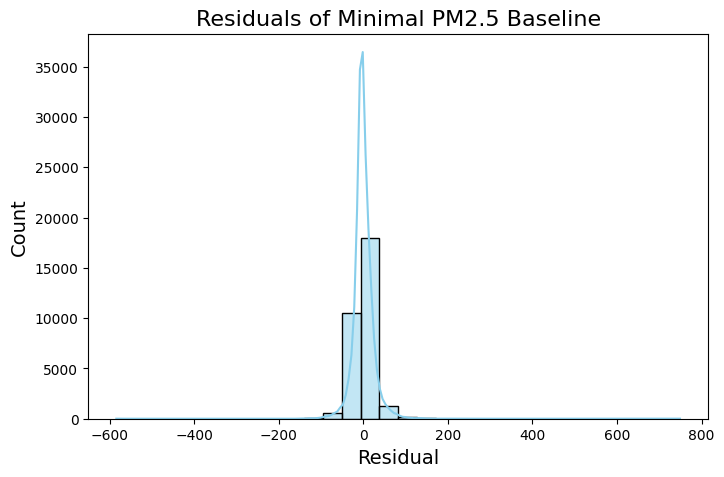

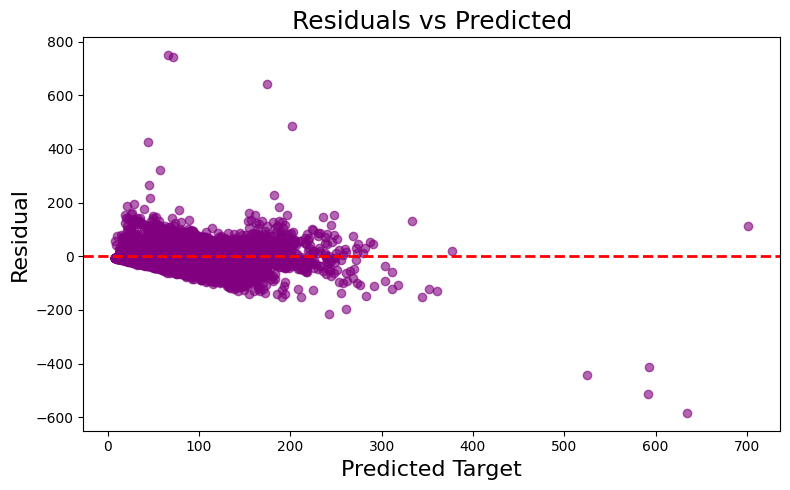

        Date  target  predicted_target
3 2020-01-05    49.0         30.734418
4 2020-01-06    21.0         48.471317
5 2020-01-07    28.0         27.439718
6 2020-01-08    21.0         34.806665
7 2020-01-09    18.0         26.120763


In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1️ Load training dataset
# ----------------------------
data = pd.read_csv("Train.csv", parse_dates=['Date'])

# ----------------------------
# 2️ Create minimal lagged features
# ----------------------------
data['PM2.5_lag_1'] = data['target'].shift(1)
data['PM2.5_lag_2'] = data['target'].shift(2)
data['PM2.5_roll_3'] = data['target'].shift(1).rolling(3).mean()
data['day_of_week'] = data['Date'].dt.dayofweek

lag_cols = ['PM2.5_lag_1', 'PM2.5_lag_2', 'PM2.5_roll_3', 'day_of_week']

# Drop rows with NaN due to lagging
df_model = data.dropna(subset=lag_cols + ['target'])

# ----------------------------
# 3️ Prepare features and target
# ----------------------------
X_lr = df_model[lag_cols]
y_lr = df_model['target']

# ----------------------------
# 4️ Train Linear Regression
# ----------------------------
model = LinearRegression()
model.fit(X_lr, y_lr)

# ----------------------------
# 5Predict on the same dataset
# ----------------------------
df_model['predicted_target'] = model.predict(X_lr)

# ----------------------------
# 6️ Compute metrics
# ----------------------------
residuals = df_model['target'] - df_model['predicted_target']
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
r2 = model.score(X_lr, y_lr)

print("Metrics on training data:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# ----------------------------
# 7️⃣ Residual plots
# ----------------------------
fontsize = 16

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color='skyblue', edgecolor='black')
plt.xlabel('Residual', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Residuals of Minimal PM2.5 Baseline', fontsize=16)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df_model['predicted_target'], residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Target', fontsize=fontsize)
plt.ylabel('Residual', fontsize=fontsize)
plt.title('Residuals vs Predicted', fontsize=fontsize+2)
plt.tight_layout()
plt.show()

# ----------------------------
# 8 Show predicted vs actual
# ----------------------------
print(df_model[['Date', 'target', 'predicted_target']].head())

RMSE: 43.87, MAE: 31.90, R²: 0.13


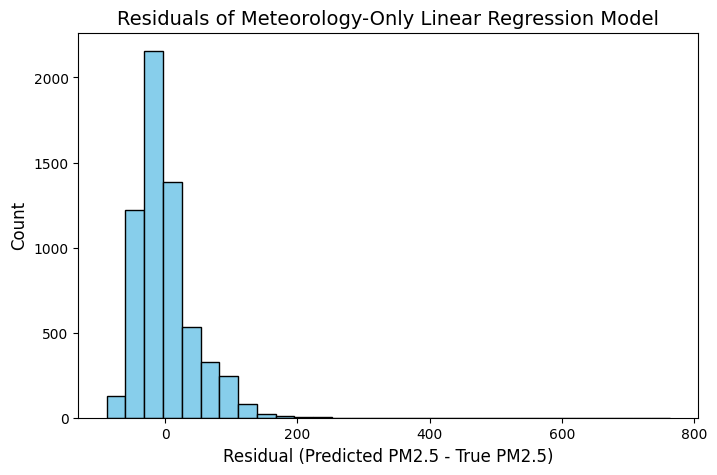

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Select features and target
# -----------------------------
X = X_train[['temperature_2m_above_ground',
             'precipitable_water_entire_atmosphere',
             'relative_humidity_2m_above_ground',
             'specific_humidity_2m_above_ground',
             'u_component_of_wind_10m_above_ground',
             'v_component_of_wind_10m_above_ground']]

y = X_train['target']

# -----------------------------
# Feature engineering
# -----------------------------
# Temperature × Humidity
X['temp_humidity'] = X['temperature_2m_above_ground'] * X['relative_humidity_2m_above_ground']
# Wind speed magnitude
X['wind_speed'] = np.sqrt(X['u_component_of_wind_10m_above_ground']**2 + 
                          X['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
#  Split into train and validation
# -----------------------------
X_train_pm, X_val_pm, y_train_pm, y_val_pm = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
#  Train linear regression
# -----------------------------
model = LinearRegression()
model.fit(X_train_pm, y_train_pm)

# Predict
y_pred_pm = model.predict(X_val_pm)

# -----------------------------
#  Metrics
# -----------------------------
rmse = mean_squared_error(y_val_pm, y_pred_pm, squared=False)
mae = mean_absolute_error(y_val_pm, y_pred_pm)
r2 = r2_score(y_val_pm, y_pred_pm)

print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")

# -----------------------------
# Residual histogram
# -----------------------------
residuals = y_val_pm - y_pred_pm
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Residual (Predicted PM2.5 - True PM2.5)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Residuals of Meteorology-Only Linear Regression Model", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()



## 1 Physics-Inspired PM2.5 Formula

We combine emissions, chemistry, and meteorology into a simplified model:

$$
\text{PM}_{2.5} =
\underbrace{\alpha_1 E}_{\text{primary emissions}}
+
\underbrace{\alpha_2 (SO_2 + NO_x + VOCs)}_{\text{secondary formation}}
+
\underbrace{\alpha_3 \cdot RH}_{\text{humidity effect}}
+
\underbrace{\alpha_4 \cdot T}_{\text{temperature effect}}
-
\underbrace{\alpha_5 \cdot W}_{\text{wind dispersion}}
+
\epsilon
$$

---

## 2 Interpretation

- **$E$ (Emissions)** → Direct pollution (traffic, industry, biomass burning)  
- **$SO_2, NO_x, VOCs$ (Chemical precursors)** → Form secondary particles (sulfates, nitrates, organic aerosols)  
- **$RH$ (Relative Humidity)** → Enhances particle formation → ↑ PM2.5  
- **$T$ (Temperature)** → Influences atmospheric chemical reactions  
- **$W$ (Wind Speed)** → Disperses pollutants → ↓ PM2.5  
- **$\epsilon$ (Error term)** → Noise, unknown sources, measurement uncertainty  

---

## 3 Emission Breakdown

$$
E = E_{\text{traffic}} + E_{\text{industry}} + E_{\text{biomass}} + E_{\text{other}}
$$

- **Traffic** → vehicles, urban congestion  
- **Industry** → factories, power plants  
- **Biomass** → burning, agriculture, wildfires  
- **Other** → dust, construction, natural sources  

---

## 4 Insight

This equation shows that PM2.5 is driven by:

- **Direct emissions (E)**  
- **Chemical transformation (SO₂, NOₓ, VOCs)**  
- **Meteorology (RH, T, W)**  


RMSE: 37.46, MAE: 26.70, R²: 0.36


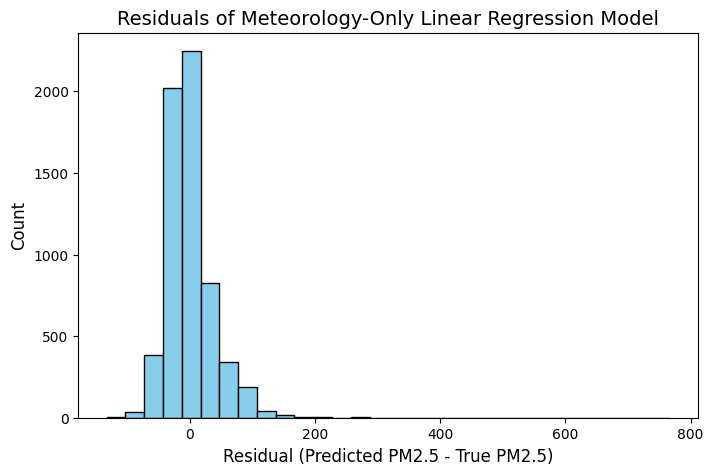

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
#  Select features and target
# -----------------------------
X = X_train[['precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground',
       'L3_NO2_NO2_column_number_density',
       'L3_NO2_NO2_slant_column_number_density',
       'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction',
       'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle',
       'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle',
       'L3_NO2_solar_zenith_angle',
       'L3_NO2_stratospheric_NO2_column_number_density',
       'L3_NO2_tropopause_pressure',
       'L3_NO2_tropospheric_NO2_column_number_density',
       'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature',
       'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle',
       'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle',
       'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_density',
       'L3_CO_H2O_column_number_density', 'L3_CO_cloud_height',
       'L3_CO_sensor_altitude', 'L3_CO_sensor_azimuth_angle',
       'L3_CO_sensor_zenith_angle', 'L3_CO_solar_azimuth_angle',
       'L3_CO_solar_zenith_angle', 'L3_HCHO_HCHO_slant_column_number_density',
       'L3_HCHO_cloud_fraction', 'L3_HCHO_sensor_azimuth_angle',
       'L3_HCHO_sensor_zenith_angle', 'L3_HCHO_solar_azimuth_angle',
       'L3_HCHO_solar_zenith_angle',
       'L3_HCHO_tropospheric_HCHO_column_number_density',
       'L3_HCHO_tropospheric_HCHO_column_number_density_amf',
       'L3_CLOUD_cloud_base_height', 'L3_CLOUD_cloud_base_pressure',
       'L3_CLOUD_cloud_fraction', 'L3_CLOUD_cloud_optical_depth',
       'L3_CLOUD_cloud_top_height', 'L3_CLOUD_cloud_top_pressure',
       'L3_CLOUD_sensor_azimuth_angle', 'L3_CLOUD_sensor_zenith_angle',
       'L3_CLOUD_solar_azimuth_angle', 'L3_CLOUD_solar_zenith_angle',
       'L3_CLOUD_surface_albedo', 'L3_AER_AI_absorbing_aerosol_index',
       'L3_AER_AI_sensor_altitude', 'L3_AER_AI_sensor_azimuth_angle',
       'L3_AER_AI_sensor_zenith_angle', 'L3_AER_AI_solar_azimuth_angle',
       'L3_AER_AI_solar_zenith_angle', 'L3_SO2_SO2_column_number_density',
       'L3_SO2_SO2_column_number_density_amf',
       'L3_SO2_SO2_slant_column_number_density',
       'L3_SO2_absorbing_aerosol_index', 'L3_SO2_cloud_fraction',
       'L3_SO2_sensor_azimuth_angle', 'L3_SO2_sensor_zenith_angle',
       'L3_SO2_solar_azimuth_angle', 'L3_SO2_solar_zenith_angle']]

y = X_train['target']

# -----------------------------
#  Split into train and validation
# -----------------------------
X_train_pm, X_val_pm, y_train_pm, y_val_pm = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
#  Train linear regression
# -----------------------------
model = LinearRegression()
model.fit(X_train_pm, y_train_pm)

# Predict
y_pred_pm = model.predict(X_val_pm)

# -----------------------------
#  Metrics
# -----------------------------
rmse = mean_squared_error(y_val_pm, y_pred_pm, squared=False)
mae = mean_absolute_error(y_val_pm, y_pred_pm)
r2 = r2_score(y_val_pm, y_pred_pm)

print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")

# -----------------------------
# Residual histogram
# -----------------------------
residuals = y_val_pm - y_pred_pm
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Residual (Predicted PM2.5 - True PM2.5)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Residuals of Meteorology-Only Linear Regression Model", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()



Random Forest Metrics -> RMSE: 34.18, MAE: 23.34, R²: 0.47


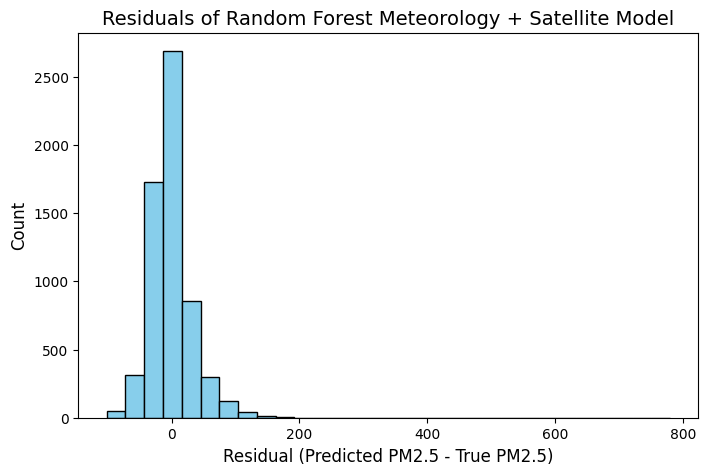

Top 10 Features by Importance:
L3_CO_CO_column_number_density                     0.207876
wind_speed                                         0.136008
L3_HCHO_tropospheric_HCHO_column_number_density    0.091087
temp_humidity                                      0.065715
L3_O3_O3_column_number_density                     0.057838
L3_AER_AI_absorbing_aerosol_index                  0.057228
temperature_2m_above_ground                        0.055893
L3_NO2_tropospheric_NO2_column_number_density      0.050643
relative_humidity_2m_above_ground                  0.045993
v_component_of_wind_10m_above_ground               0.043195
dtype: float64


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
#  Select features
# -----------------------------
meteorology = ['temperature_2m_above_ground',
               'precipitable_water_entire_atmosphere',
               'relative_humidity_2m_above_ground',
               'specific_humidity_2m_above_ground',
               'u_component_of_wind_10m_above_ground',
               'v_component_of_wind_10m_above_ground']

satellite = ['L3_NO2_tropospheric_NO2_column_number_density',
             'L3_CO_CO_column_number_density',
             'L3_O3_O3_column_number_density',
             'L3_HCHO_tropospheric_HCHO_column_number_density',
             'L3_SO2_SO2_column_number_density',
             'L3_AER_AI_absorbing_aerosol_index',
             'L3_CLOUD_cloud_fraction']

features = meteorology + satellite
X = X_train[features].copy()
y = X_train['target'].copy()



# -----------------------------
# Feature engineering
# -----------------------------
X['temp_humidity'] = X['temperature_2m_above_ground'] * X['relative_humidity_2m_above_ground']
X['wind_speed'] = np.sqrt(X['u_component_of_wind_10m_above_ground']**2 + 
                          X['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
# 4️⃣ Train-test split
# -----------------------------
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# 5️⃣ Train Random Forest
# -----------------------------
rf = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
rf.fit(X_train_rf, y_train_rf)

# Predict
y_pred_rf = rf.predict(X_val_rf)

# -----------------------------
# 6️⃣ Metrics
# -----------------------------
rmse = mean_squared_error(y_val_rf, y_pred_rf, squared=False)
mae = mean_absolute_error(y_val_rf, y_pred_rf)
r2 = r2_score(y_val_rf, y_pred_rf)
print(f"Random Forest Metrics -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")

# -----------------------------
# 7️⃣ Residual histogram
# -----------------------------
residuals = y_val_rf - y_pred_rf
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Residual (Predicted PM2.5 - True PM2.5)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Residuals of Random Forest Meteorology + Satellite Model", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# -----------------------------
# 8️⃣ Feature importance
# -----------------------------
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 Features by Importance:")
print(importances.head(10))

Random Forest Metrics -> RMSE: 30.62, MAE: 20.59, R²: 0.57


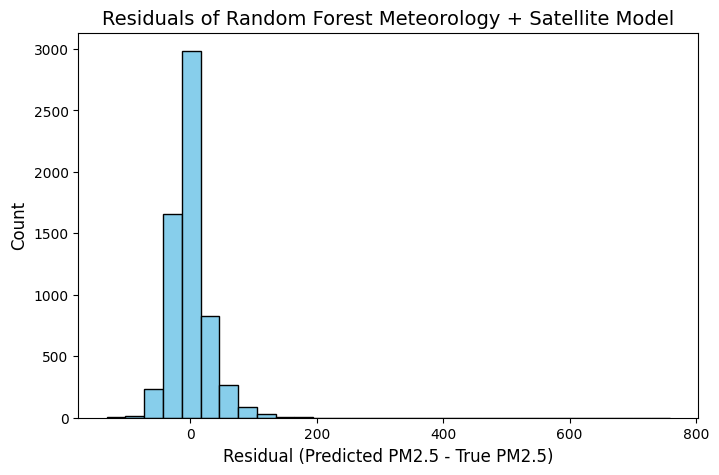

Top 10 Features by Importance:
L3_CO_CO_column_number_density                         0.167853
wind_speed                                             0.101078
L3_AER_AI_sensor_altitude                              0.070461
L3_NO2_NO2_slant_column_number_density                 0.065481
L3_HCHO_tropospheric_HCHO_column_number_density        0.047186
temperature_2m_above_ground                            0.025208
temp_humidity                                          0.024761
L3_NO2_NO2_column_number_density                       0.023074
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.021466
L3_CLOUD_surface_albedo                                0.019075
dtype: float64


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


X = X_train[['precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground',
       'L3_NO2_NO2_column_number_density',
       'L3_NO2_NO2_slant_column_number_density',
       'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction',
       'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle',
       'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle',
       'L3_NO2_solar_zenith_angle',
       'L3_NO2_stratospheric_NO2_column_number_density',
       'L3_NO2_tropopause_pressure',
       'L3_NO2_tropospheric_NO2_column_number_density',
       'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature',
       'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle',
       'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle',
       'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_density',
       'L3_CO_H2O_column_number_density', 'L3_CO_cloud_height',
       'L3_CO_sensor_altitude', 'L3_CO_sensor_azimuth_angle',
       'L3_CO_sensor_zenith_angle', 'L3_CO_solar_azimuth_angle',
       'L3_CO_solar_zenith_angle', 'L3_HCHO_HCHO_slant_column_number_density',
       'L3_HCHO_cloud_fraction', 'L3_HCHO_sensor_azimuth_angle',
       'L3_HCHO_sensor_zenith_angle', 'L3_HCHO_solar_azimuth_angle',
       'L3_HCHO_solar_zenith_angle',
       'L3_HCHO_tropospheric_HCHO_column_number_density',
       'L3_HCHO_tropospheric_HCHO_column_number_density_amf',
       'L3_CLOUD_cloud_base_height', 'L3_CLOUD_cloud_base_pressure',
       'L3_CLOUD_cloud_fraction', 'L3_CLOUD_cloud_optical_depth',
       'L3_CLOUD_cloud_top_height', 'L3_CLOUD_cloud_top_pressure',
       'L3_CLOUD_sensor_azimuth_angle', 'L3_CLOUD_sensor_zenith_angle',
       'L3_CLOUD_solar_azimuth_angle', 'L3_CLOUD_solar_zenith_angle',
       'L3_CLOUD_surface_albedo', 'L3_AER_AI_absorbing_aerosol_index',
       'L3_AER_AI_sensor_altitude', 'L3_AER_AI_sensor_azimuth_angle',
       'L3_AER_AI_sensor_zenith_angle', 'L3_AER_AI_solar_azimuth_angle',
       'L3_AER_AI_solar_zenith_angle', 'L3_SO2_SO2_column_number_density',
       'L3_SO2_SO2_column_number_density_amf',
       'L3_SO2_SO2_slant_column_number_density',
       'L3_SO2_absorbing_aerosol_index', 'L3_SO2_cloud_fraction',
       'L3_SO2_sensor_azimuth_angle', 'L3_SO2_sensor_zenith_angle',
       'L3_SO2_solar_azimuth_angle', 'L3_SO2_solar_zenith_angle']].copy()
y = X_train['target'].copy()



# -----------------------------
#  Feature engineering
# -----------------------------
X['temp_humidity'] = X['temperature_2m_above_ground'] * X['relative_humidity_2m_above_ground']
X['wind_speed'] = np.sqrt(X['u_component_of_wind_10m_above_ground']**2 + 
                          X['v_component_of_wind_10m_above_ground']**2)

# -----------------------------
#  Train-test split
# -----------------------------
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
#  Train Random Forest
# -----------------------------
rf = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
rf.fit(X_train_rf, y_train_rf)

# Predict
y_pred_rf = rf.predict(X_val_rf)

# -----------------------------
# Metrics
# -----------------------------
rmse = mean_squared_error(y_val_rf, y_pred_rf, squared=False)
mae = mean_absolute_error(y_val_rf, y_pred_rf)
r2 = r2_score(y_val_rf, y_pred_rf)
print(f"Random Forest Metrics -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")

# -----------------------------
# 7️⃣ Residual histogram
# -----------------------------
residuals = y_val_rf - y_pred_rf
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Residual (Predicted PM2.5 - True PM2.5)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Residuals of Random Forest Meteorology + Satellite Model", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# -----------------------------
# 8️⃣ Feature importance
# -----------------------------
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 Features by Importance:")
print(importances.head(10))

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ----------------------------
# X-axis: dates
# ----------------------------
if 'Date' in train.columns and not train['Date'].isnull().all():
    train_x = pd.to_datetime(train['Date'])
    test_x = pd.to_datetime(test['Date'])
    use_dates = True
else:
    train_x = np.arange(len(y_train))
    test_x = np.arange(len(y_train), len(y_train) + len(y_future_pred))
    use_dates = False

# ----------------------------
# PM2.5 AQI bands (µg/m³)
# Define colors for each band
# ----------------------------
aqi_bands = {
    'Good': (0, 12, '#A6D96A'),
    'Moderate': (12, 35.4, '#FFFFBF'),
    'Unhealthy for Sensitive': (35.5, 55.4, '#FDAE61'),
    'Unhealthy': (55.5, 150.4, '#F46D43'),
    'Very Unhealthy': (150.5, 250.4, '#D73027'),
    'Hazardous': (250.5, 500, '#800026')
}

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(14,6))

# AQI background bands (with distinct colors for each category)
for label, (low, high, color) in aqi_bands.items():
    plt.fill_between(
        np.concatenate([train_x, test_x]),
        low, high,
        color=color, alpha=0.15, label=label
    )

# Training actual (scatter)
plt.scatter(train_x, y_train, color='black', s=15, alpha=0.7, label='Training Actual')
# Training predicted
plt.plot(train_x, y_train_pred, color='blue', linestyle='--', label='Training Predicted')
# Future forecast
plt.plot(test_x, y_future_pred, color='red', linewidth=2, label='Future Predicted')

# Vertical line separating training and future
if use_dates:
    plt.axvline(train_x.iloc[-1], color='gray', linestyle=':', linewidth=1.5)
else:
    plt.axvline(train_x[-1], color='gray', linestyle=':', linewidth=1.5)

# Horizontal harmful threshold
harmful_level = 25
plt.axhline(harmful_level, color='darkred', linestyle='--', linewidth=2,
            label=f'Harmful Threshold ({harmful_level} µg/m³)')
plt.fill_between(
    np.concatenate([train_x, test_x]),
    harmful_level,
    max(max(y_train_pred), max(y_future_pred), harmful_level) + 5,
    color='red',
    alpha=0.1
)

# ----------------------------
# X-axis formatting
# ----------------------------
ax = plt.gca()
if use_dates:
    # Major ticks every 5 years
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    # Minor ticks every 1 year
    ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.title('PM2.5 Training, Predicted, and Future Forecast with AQI Bands', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.legend(fontsize=12, ncol=2, loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [29]:
# =============================
# 1. Imports
# =============================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# =============================
# 2. Feature Selection
# =============================
meteorology = [
    'temperature_2m_above_ground',
    'precipitable_water_entire_atmosphere',
    'relative_humidity_2m_above_ground',
    'specific_humidity_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground'
]

satellite = [
    'L3_NO2_tropospheric_NO2_column_number_density',
    'L3_CO_CO_column_number_density',
    'L3_O3_O3_column_number_density',
    'L3_HCHO_tropospheric_HCHO_column_number_density',
    'L3_SO2_SO2_column_number_density',
    'L3_AER_AI_absorbing_aerosol_index',
    'L3_CLOUD_cloud_fraction'
]

features = meteorology + satellite

# =============================
# 3. Prepare Data
# =============================
X = X_train[features].copy()
y = X_train['target'].copy()
X_test_selected = X_test[features].copy()

# =============================
# 4. Handle Missing Values (NO DATA LEAKAGE)
# =============================
train_means = X.mean()
X = X.fillna(train_means)
X_test_selected = X_test_selected.fillna(train_means)

# =============================
# 5. Feature Engineering
# =============================
def add_features(df):
    df['temp_humidity'] = df['temperature_2m_above_ground'] * df['relative_humidity_2m_above_ground']
    df['wind_speed'] = np.sqrt(
        df['u_component_of_wind_10m_above_ground']**2 +
        df['v_component_of_wind_10m_above_ground']**2
    )
    return df

X = add_features(X)
X_test_selected = add_features(X_test_selected)

# =============================
# 6. Train/Validation Split
# =============================
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# 7. Model (Improved Random Forest)
# =============================
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# =============================
# 8. Cross-Validation
# =============================
cv_scores = cross_val_score(
    rf, X_tr, y_tr,
    scoring='neg_root_mean_squared_error',
    cv=5
)

print("CV RMSE:", -cv_scores)
print("Mean CV RMSE:", -cv_scores.mean())

# =============================
# 9. Train Model
# =============================
rf.fit(X_tr, y_tr)

# =============================
# 10. Validation Evaluation
# =============================
y_val_pred = rf.predict(X_val)

rmse = mean_squared_error(y_val, y_val_pred, squared=False)
r2 = r2_score(y_val, y_val_pred)

print("Validation RMSE:", rmse)
print("Validation R²:", r2)

# =============================
# 11. Plot (Validation, NOT training)
# =============================
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, alpha=0.6)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Validation: Actual vs Predicted")
plt.grid(True)
plt.show()

# =============================
# 12. Residual Plot
# =============================
residuals = y_val - y_val_pred

plt.figure(figsize=(6,5))
plt.scatter(y_val_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (Validation)")
plt.grid(True)
plt.show()

# =============================
# 13. Train Final Model on FULL Data
# =============================
rf.fit(X, y)

# =============================
# 14. Predict on Test Data
# =============================
y_test_pred = rf.predict(X_test_selected)

# =============================
# 15. Feature Importance
# =============================
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns

print("\nTop 10 Features:")
print(importances.head(10))

TypeError: 'NoneType' object is not subscriptable

In [ ]:
if 'Date' in train.columns and not train['Date'].isnull().all(): train_dates = pd.to_datetime(train['Date']) else: train_dates = pd.date_range(start="2020-01-01", periods=len(y_train), freq='D') last_train_year = train_dates.max().year future_years = np.arange(last_train_year + 1, 2106) future_dates = pd.to_datetime([f"{y}-01-01" for y in future_years]) # Adjust y_future_pred length if len(future_dates) > len(y_future_pred): repeats = len(future_dates) - len(y_future_pred) y_future_pred = np.concatenate([y_future_pred, np.full(repeats, y_future_pred[-1])]) else: y_future_pred = y_future_pred[:len(future_dates)] # ---------------------------- # AQI Bands # ---------------------------- aqi_bands = { 'Good': (0, 12, '#A6D96A'), 'Moderate': (12, 35.4, '#FFFFBF'), 'Unhealthy for Sensitive': (35.5, 55.4, '#FDAE61'), 'Unhealthy': (55.5, 150.4, '#F46D43'), 'Very Unhealthy': (150.5, 250.4, '#D73027'), 'Hazardous': (250.5, 500, '#800026') } # ---------------------------- # Plot # ---------------------------- plt.figure(figsize=(14,6)) all_dates = pd.concat([pd.Series(train_dates), pd.Series(future_dates)]) for label, (low, high, color) in aqi_bands.items(): plt.fill_between(all_dates, low, high, color=color, alpha=0.15, label=label) plt.scatter(train_dates, y_train, color='black', s=15, alpha=0.7, label='Training Actual') plt.plot(train_dates, y_train_pred, color='blue', linestyle='--', label='Training Predicted') plt.plot(future_dates, y_future_pred, color='red', linewidth=2, label='Future Predicted') plt.axvline(train_dates.iloc[-1], color='gray', linestyle=':', linewidth=1.5) harmful_level = 25 plt.axhline(harmful_level, color='darkred', linestyle='--', linewidth=2, label=f'Harmful Threshold ({harmful_level} µg/m³)') plt.fill_between(all_dates, harmful_level, max(max(y_train_pred), max(y_future_pred), harmful_level) + 5, color='red', alpha=0.1) ax = plt.gca() ax.xaxis.set_major_locator(mdates.YearLocator(base=5)) ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) ax.xaxis.set_minor_locator(mdates.YearLocator(base=1)) plt.xticks(rotation=0, fontsize=12) plt.yticks(fontsize=12) plt.title('PM2.5 Training and Future Forecast with AQI Bands (XGBoost)', fontsize=16) plt.xlabel('Year', fontsize=14) plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14) plt.legend(fontsize=12, ncol=2, loc='upper left') plt.grid(alpha=0.2) plt.tight_layout() plt.show()